<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/SpinStar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

General Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import comb

Functions for constructing the Hamiltonian:  $H = \frac{\omega}{2}\sigma_S^x + \Omega \, \sigma_S^z \otimes \frac{1}{N}\sum_{k=1}^{N}\,\sigma_k^z$

In [ ]:
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)


# ---------------------------------------------------------------------------
# Hamiltonian construction
# ---------------------------------------------------------------------------

def _single_site_op(op, k, N):
    """Embed single-qubit operator on site k (0-indexed) in an N-qubit space."""
    factors = [op if j == k else I2 for j in range(N)]
    result = factors[0]
    for f in factors[1:]:
        result = np.kron(result, f)
    return result


def build_hamiltonian(N, omega, gamma, Omega):
    """
    H = (omega/2) sigma_s^x ⊗ I_E
      + (gamma/2N) I_s ⊗ sum_k sigma_k^x
      + (Omega/N) sigma_s^z ⊗ sum_k sigma_k^z

    The interaction term is diagonal in the computational basis of E,
    making it natural to project onto that basis.

    Args:
        N:     number of environment qubits
        omega: system transverse field strength
        gamma: environment transverse field strength
        Omega: system-environment coupling strength

    Returns:
        H: (2^(N+1), 2^(N+1)) complex Hamiltonian matrix
    """
    dim_E = 2**N
    I_E = np.eye(dim_E, dtype=complex)

    # System transverse field
    H_sys = (omega / 2) * np.kron(sigma_x, I_E)

    # System-environment interaction (diagonal in computational basis of E)
    sum_z_E = sum(_single_site_op(sigma_z, k, N) for k in range(N))
    H_int = (Omega / N) * np.kron(sigma_z, sum_z_E)

    return H_sys + H_int

Function for computing the projected ensemble.

In [ ]:
def compute_projected_ensemble(psi, N):
    """
    Project the joint state onto the computational basis of the environment.

    For each outcome m in {0,...,2^N-1} the (unnormalized) system state is
        |phi_m> = <m|_E |psi>,
    with probability p_m = ||phi_m||^2.

    The normalized state is parameterized as
        |phi_m> = sqrt(p) |0> + sqrt(1-p) e^{i phi} |1>
    (global phase removed by making the |0> coefficient real and non-negative).

    Args:
        psi: (2^(N+1),) joint state vector
        N:   number of environment qubits

    Returns:
        probs   : (M,) measurement probabilities p_m  (M <= 2^N)
        p_vals  : (M,) qubit population  p = |<0|phi_m>|^2
        phi_vals: (M,) relative phase    phi in [-pi, pi]
    """
    psi_mat = psi.reshape(2, 2**N)  # row = system index, col = env outcome m

    probs, p_vals, phi_vals = [], [], []
    for m in range(2**N):
        unnorm = psi_mat[:, m]
        prob = float(np.real(unnorm.conj() @ unnorm))
        if prob < 1e-12:
            continue

        phi_m = unnorm / np.sqrt(prob)
        alpha, beta = phi_m[0], phi_m[1]

        # Fix global phase: rotate so alpha is real and non-negative
        if abs(alpha) > 1e-12:
            phase = np.angle(alpha)
            alpha = alpha * np.exp(-1j * phase)
            beta  = beta  * np.exp(-1j * phase)

        p   = float(np.real(alpha.conj() * alpha))
        phi = float(np.angle(beta)) % (2 * np.pi)

        probs.append(prob)
        p_vals.append(p)
        phi_vals.append(phi)

    return np.array(probs), np.array(p_vals), np.array(phi_vals)

Construct Initial State as $|\Psi_{SE}^0\rangle = |0\rangle \otimes \left( \cos\frac{\theta}{2}|0\rangle + \sin\frac{\theta}{2}|1\rangle \right)^{\otimes N} $
where $\theta = \arccos(m_0) $ with $m_0 = \langle\sigma_z\rangle$ being the net magnetization of the environment.

In [ ]:
def make_initial_state(N, m0):
    theta = np.arccos(m0)
    psi_e = np.array([np.cos(theta / 2), np.sin(theta / 2)], dtype=complex)
    psi_s = np.array([1, 0], dtype=complex)

    psi_E = psi_e
    for _ in range(N - 1):
        psi_E = np.kron(psi_E, psi_e)
    return np.kron(psi_s, psi_E)

Example evolution of the system using `build_hamiltonian` and `make_initial_state`.

In [ ]:
def evolve_spin_star(H, psi0, N, times):
  E, V = np.linalg.eigh(H)
  c0 = V.conj().T @ psi0

  probs_all, p_vals_all, phi_vals_all = [], [], []
  for t in times:
      psi_t = V @ (np.exp(-1j * E * t) * c0)
      probs, p_vals, phi_vals = compute_projected_ensemble(psi_t, N)
      probs_all.append(probs)
      p_vals_all.append(p_vals)
      phi_vals_all.append(phi_vals)
  return probs_all, p_vals_all, phi_vals_all


# MODEL_PARAMS
N = 8
omega = 1.0
Omega = 0.5
m0 = 0.5 # Spin coherent environment state, takes value between, 0 and 1
t0 = 0.0
t1 = 400.0
n_timesteps = 6000

# RUN MODEL DYNAMICS
H = build_hamiltonian(N, omega, gamma=0.0, Omega=Omega)
psi0 = make_initial_state(N, m0)

times = np.linspace(t0, t1, n_timesteps, endpoint=False)

probs_t, p_vals_t, phi_vals_t = evolve_spin_star(H, psi0, N, times)

Outputs three arrays. Assuming ensemble is written as collections of $(q, p, \phi)$, each entry in `probs_t`, `p_vals_t`, and `phi_vals_t` corresponds to the collected $q$, $p$, $\phi$ values per timestep.

Quick check that this produces the proper time-averaged plot

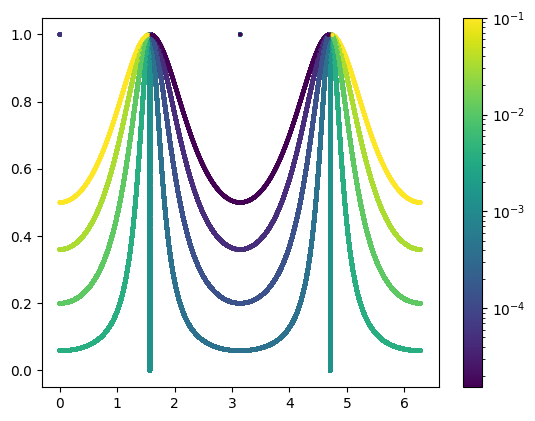

In [ ]:
probs_tavg = np.concatenate(probs_t)
p_vals_tavg = np.concatenate(p_vals_t)
phi_vals_tavg = np.concatenate(phi_vals_t)

plt.figure()
plt.scatter(phi_vals_tavg, p_vals_tavg, s=4, c=probs_tavg, norm=LogNorm())
plt.colorbar()